# NOTEBOOK: Generate Figures and Tables for Optimization Learning Task

⚠️ **IMPORTANT: Configure WandB Project Names**

This notebook pulls data from various WandB projects. You'll need to update the project names in the beginning of each section to match your own WandB projects if you want to use your own data.

**To use your own WandB data:**
1. Update the `WANDB_WORKSPACE` variable in cell 2 to match your WandB workspace/entity name
2. In each section below, modify the project name suffix (currently `_Feb03`, `_lambd_Feb03`, etc.) to match your WandB project names

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import sys
from pathlib import Path

# Add root directory to system path for imports
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir))

FIGURE_SAVE_DIR = os.path.join(root_dir, 'figures')
os.makedirs(FIGURE_SAVE_DIR, exist_ok=True)

###############################################################################
#################### Replace with your WANDB workspace ########################
###############################################################################
WANDB_WORKSPACE = "ConstrainedNN"
###############################################################################
###############################################################################
###############################################################################

HPROJ_SEEDS = [123, 456, 789, 101, 112]

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

# Login to Weights & Biases
wandb.login()

# Initialize API
api = wandb.Api(timeout=29)

wandb: Currently logged in as: ycchu (ConstrainedNN) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
from utils.plot_table_utils import get_runs_dfs
from utils.plot_table_utils import plot_opt_metrics
from utils.plot_table_utils import generate_test_metrics_latex_table_from_df
from utils.plot_table_utils import plot_test_metrics_bars
from utils.plot_table_utils import plot_test_metrics_bars_groups
from utils.plot_table_utils import plot_legend

# `noncvx` Comparison

In [ ]:
problem = 'noncvx'

###############################################################################
#################### Replace with your WANDB project name #####################
###############################################################################
main_project = f"{problem}_comparison_Feb03"
hproj_project = f"HProj_{problem}_Bd100_var100_ineq50_eq50"
###############################################################################
###############################################################################
###############################################################################

In [ ]:
# Get run history and test metrics dataframes
hist_df1, test_df1 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=main_project)
hist_df2, test_df2 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=hproj_project)

In [ ]:
# Filter for 5 seeds for HProj runs
hist_df2 = hist_df2[hist_df2['seed'].isin(HPROJ_SEEDS)]
test_df2 = test_df2[test_df2['seed'].isin(HPROJ_SEEDS)]

In [ ]:
# Combine dataframes for plotting
hist_df = pd.concat([hist_df1, hist_df2], ignore_index=True)
test_df = pd.concat([test_df1, test_df2], ignore_index=True)

In [10]:
# Summarize runs in hist_df
print("Summary of runs in hist_df:")
print("="*60)

# Group by model
models = hist_df['model'].unique()
for model_name in sorted(models):
    model_df = hist_df[hist_df['model'] == model_name]
    method_names = model_df['method_name'].unique()
    
    print(f"\nModel: {model_name}")
    print(f"  Number of hyperparameter configurations: {len(method_names)}")
    
    for method_name in sorted(method_names):
        method_df = model_df[model_df['method_name'] == method_name]
        
        # Get method params from method_name (format: model_params)
        method_params = '_'.join(method_name.split('_')[1:])
        
        # Get unique seeds
        seeds = method_df['seed'].unique().tolist()
        num_seeds = len(seeds)
        
        # Get epoch range
        epochs = method_df['epoch'].values
        min_epoch = epochs.min() if len(epochs) > 0 else 0
        max_epoch = epochs.max() if len(epochs) > 0 else 0
        
        print(f"    - {method_params}:")
        print(f"        Number of seeds: {num_seeds}")
        print(f"        Seeds: {seeds}")
        print(f"        Epochs logged: {min_epoch} - {max_epoch}")

print("\n" + "="*60)
print(f"Total unique methods: {len(hist_df['method_name'].unique())}")
print(f"Total runs (seed × method): {len(hist_df.groupby(['method_name', 'seed']))}")

Summary of runs in hist_df:

Model: dc3
  Number of hyperparameter configurations: 1
    - trainCorr10_testCorr10_corrLr1e-07_corrEps0.0001:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 1999.0

Model: hardnetaff
  Number of hyperparameter configurations: 1
    - no_hyperparams_soft100:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 1999.0

Model: hproj
  Number of hyperparameter configurations: 1
    - H_Bis:
        Number of seeds: 5
        Seeds: [456, 789, 112, 123, 101]
        Epochs logged: nan - nan

Model: snarenet
  Number of hyperparameter configurations: 5
    - pinv_lambda0.01_adaRel500_rtol0.0001:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 1999.0
    - pinv_lambda0.01_adaRel500_rtol1e-06:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 1999.0
    - pinv_lambda0.01_adaRe

## Training Dynamics Plots

In [12]:
# Specify which methods and display names
methods_to_include = {
    'dc3_trainCorr10_testCorr10_corrLr1e-07_corrEps0.0001': 'DC3',
    'hardnetaff_no_hyperparams_soft100':                    'HardNet',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-12':         'SnareNet ($\mathtt{tol}=10^{-12}$)',
}

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_opt_metrics_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_opt_metrics_gmean_nolegend.png'


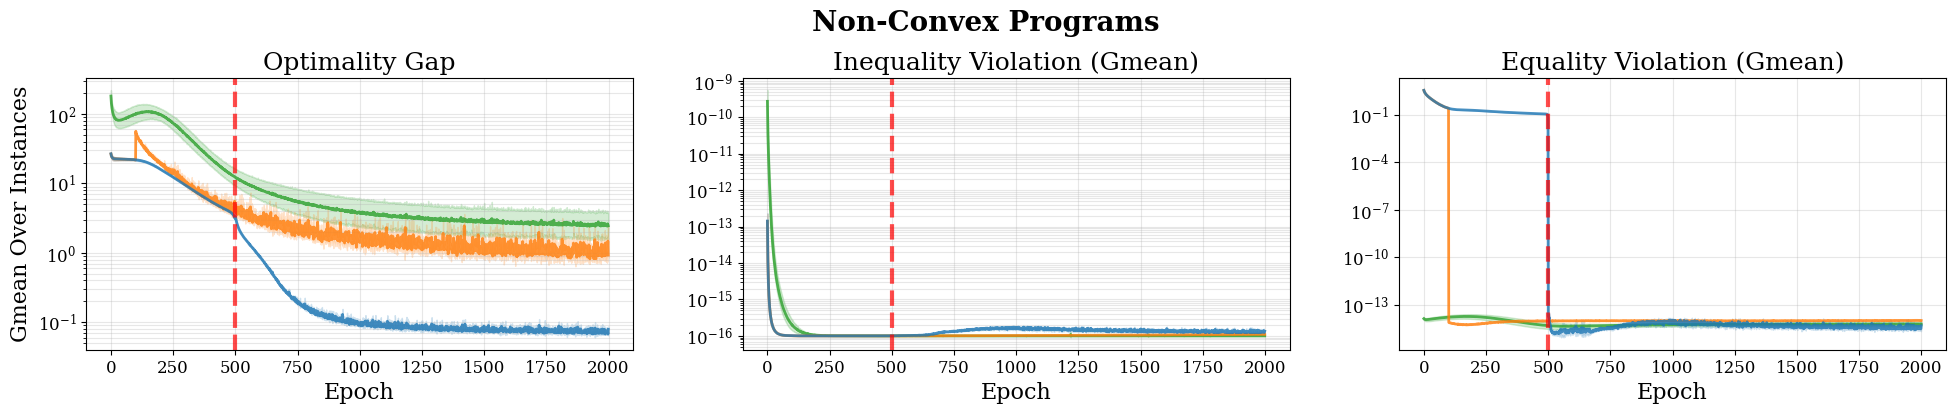

In [13]:
metric_agg = 'gmean'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_opt_metrics(
    history_df=hist_df, 
    methods_to_include=methods_to_include,
    metric_agg=metric_agg,
    figsize=(24, 4),
    show_legend=show_legend,
    suptitle="Non-Convex Programs",
    vline_epoch=500,  # Add vertical red dashed line at epoch 500
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_opt_metrics_{metric_agg}{legend_txt}'))
plt.show()

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_opt_metrics_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_opt_metrics_max_nolegend.png'


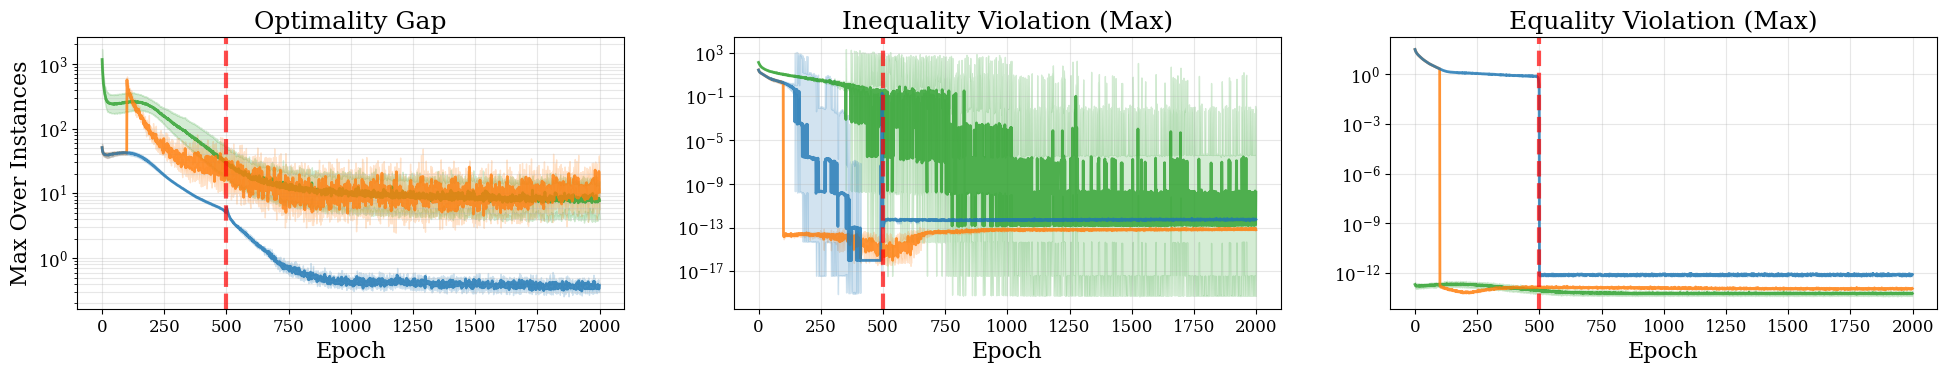

In [14]:
metric_agg = 'max'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_opt_metrics(
    history_df=hist_df, 
    methods_to_include=methods_to_include,
    metric_agg=metric_agg,
    figsize=(24, 4),
    show_legend=show_legend,
    vline_epoch=500,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_opt_metrics_{metric_agg}{legend_txt}'))
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_line_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_line_legend.png'


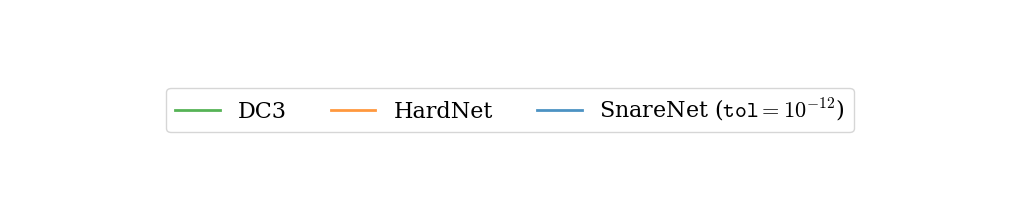

In [15]:
legend_type = 'line'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=hist_df,
    legend_type=legend_type,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_{legend_type}_legend'))
plt.show()

## Test Metrics Bar Chart

In [16]:
# Specify which methods and display names
methods_to_include = {
    'dc3_trainCorr10_testCorr10_corrLr1e-07_corrEps0.0001': 'DC3',
    'hardnetaff_no_hyperparams_soft100':                    'HardNet',
    'hproj_H_Bis':                                          'HProj',
    'snarenet_pinv_lambda0.01_adaRel500_rtol0.0001':       'SnareNet ($\mathtt{tol}=10^{-4}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-06':        'SnareNet ($\mathtt{tol}=10^{-6}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-08':        'SnareNet ($\mathtt{tol}=10^{-8}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-10':        'SnareNet ($\mathtt{tol}=10^{-10}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-12':        'SnareNet ($\mathtt{tol}=10^{-12}$)',
}

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_test_metrics_bars_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_test_metrics_bars_gmean_nolegend.png'


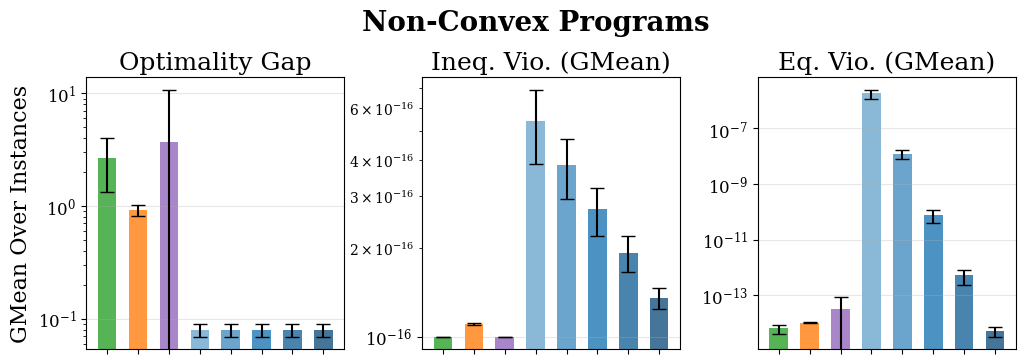

In [17]:
# Plot test metrics as bar charts
metric_agg = 'gmean'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=test_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/ineq_err_{metric_agg}', f'test/eq_err_{metric_agg}'],
    figsize=(12, 4),
    show_legend=show_legend,
    share_ylabel=True,
    suptitle="Non-Convex Programs",
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_test_metrics_bars_{metric_agg}{legend_txt}'))
plt.show()

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_test_metrics_bars_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_test_metrics_bars_max_nolegend.png'


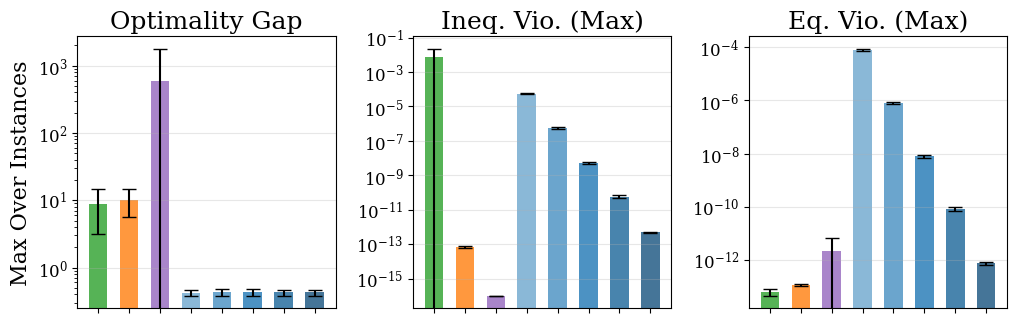

In [18]:
# Plot test metrics as bar charts
metric_agg = 'max'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=test_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/ineq_err_{metric_agg}', f'test/eq_err_{metric_agg}'],
    figsize=(12, 4),
    share_ylabel=True,
    show_legend=show_legend,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_test_metrics_bars_{metric_agg}{legend_txt}'))
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_bar_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_bar_legend.png'


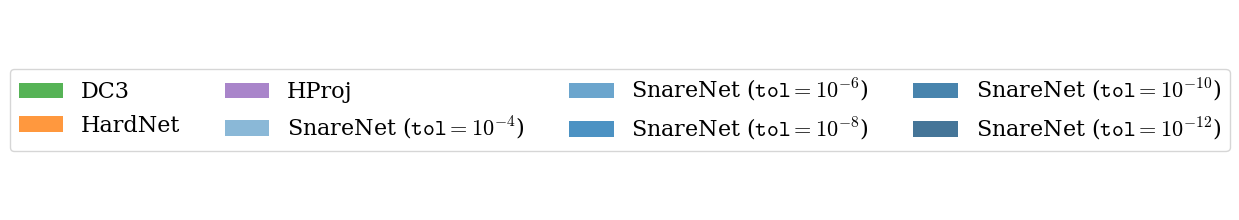

In [19]:
legend_type = 'bar'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=hist_df,
    legend_type=legend_type,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_{legend_type}_legend'))
plt.show()

## Test Metrics Table

In [20]:
# Generate latex code for test metrics table
table = generate_test_metrics_latex_table_from_df(
    test_df=test_df, 
    methods_to_include=methods_to_include)

print(table)

\begin{table*}[h]
\centering
\caption{Evaluation metrics on the test set. Values shown as mean $\pm$ std across random seeds.}
\label{tab:test_metrics}
\resizebox{\linewidth}{!}{
\begingroup
\begin{tabular}{lcccccccc}
\toprule
Method & Max Opt. Gap & GMean Opt. Gap & GMean Ineq. Error & \# Ineq Violations & Max Eq. Error & GMean Eq. Error & \# Eq Violations & Test Time (s) \\
\midrule
DC3 & $8.81 \pm 5.68$ & $2.68 \pm 1.35$ & $(1.00 \pm 0.00) \times 10^{-16}$ & $(2.40 \pm 5.37) \times 10^{-4}$ & $(6.03 \pm 1.61) \times 10^{-14}$ & $(6.46 \pm 2.27) \times 10^{-15}$ & $0.00$ & $0.19 \pm 0.07$ \\
HardNet & $(1.02 \pm 0.47) \times 10^{1}$ & $(9.17 \pm 0.99) \times 10^{-1}$ & $(1.10 \pm 0.01) \times 10^{-16}$ & $0.00$ & $(1.13 \pm 0.14) \times 10^{-13}$ & $(1.04 \pm 0.03) \times 10^{-14}$ & $0.00$ & $0.12 \pm 0.04$ \\
HProj & $(5.97 \pm 12.04) \times 10^{2}$ & $3.72 \pm 7.12$ & $0.00$ & $0.00$ & $(2.24 \pm 4.49) \times 10^{-12}$ & $(3.12 \pm 5.58) \times 10^{-14}$ & $0.00$ & $0.05 \pm 0.03$

# `cvx_qcqp` Comparison

In [ ]:
problem = 'cvx_qcqp'

###############################################################################
#################### Replace with your WANDB project name #####################
###############################################################################
main_project = f"{problem}_comparison_Feb03"
hproj_project = f"HProj_{problem}_Bd100_var100_ineq50_eq50"
###############################################################################
###############################################################################
###############################################################################

/home/ycchu97/HardConstrainedNN/plot_table_utils.py:220: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(history_dfs, ignore_index=True)


In [ ]:
# Get run history and test metrics dataframes
hist_df1, test_df1 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=main_project)
hist_df2, test_df2 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=hproj_project)

In [7]:
# Filter to only include HPORJ seeds
hist_df2 = hist_df2[hist_df2['seed'].isin(HPROJ_SEEDS)]
test_df2 = test_df2[test_df2['seed'].isin(HPROJ_SEEDS)]

In [8]:
hist_df = pd.concat([hist_df1, hist_df2], ignore_index=True)
test_df = pd.concat([test_df1, test_df2], ignore_index=True)

In [9]:
# Summarize runs in hist_df
print("Summary of runs in hist_df:")
print("="*60)

# Group by model
models = hist_df['model'].unique()
for model_name in sorted(models):
    model_df = hist_df[hist_df['model'] == model_name]
    method_names = model_df['method_name'].unique()
    
    print(f"\nModel: {model_name}")
    print(f"  Number of hyperparameter configurations: {len(method_names)}")
    
    for method_name in sorted(method_names):
        method_df = model_df[model_df['method_name'] == method_name]
        
        # Get method params from method_name (format: model_params)
        method_params = '_'.join(method_name.split('_')[1:])
        
        # Get unique seeds
        seeds = method_df['seed'].unique().tolist()
        num_seeds = len(seeds)
        
        # Get epoch range
        epochs = method_df['epoch'].values
        min_epoch = epochs.min() if len(epochs) > 0 else 0
        max_epoch = epochs.max() if len(epochs) > 0 else 0
        
        print(f"    - {method_params}:")
        print(f"        Number of seeds: {num_seeds}")
        print(f"        Seeds: {seeds}")
        print(f"        Epochs logged: {min_epoch} - {max_epoch}")

print("\n" + "="*60)
print(f"Total unique methods: {len(hist_df['method_name'].unique())}")
print(f"Total runs (seed × method): {len(hist_df.groupby(['method_name', 'seed']))}")

Summary of runs in hist_df:

Model: dc3
  Number of hyperparameter configurations: 2
    - trainCorr10_testCorr10_corrLr1e-12_corrEps0.0001:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 999.0
    - trainCorr10_testCorr10_corrLr1e-13_corrEps0.0001:
        Number of seeds: 5
        Seeds: [789, 123, 456, 101, 112]
        Epochs logged: 0.0 - 999.0

Model: hproj
  Number of hyperparameter configurations: 1
    - H_Bis:
        Number of seeds: 5
        Seeds: [789, 112, 456, 101, 123]
        Epochs logged: nan - nan

Model: snarenet
  Number of hyperparameter configurations: 5
    - pinv_lambda0.01_adaRel500_rtol0.0001:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 999.0
    - pinv_lambda0.01_adaRel500_rtol1e-06:
        Number of seeds: 5
        Seeds: [456, 789, 123, 101, 112]
        Epochs logged: 0.0 - 999.0
    - pinv_lambda0.01_adaRel500_rtol1e-08:
        Number of seeds: 5

## Training Dynamics Plots

In [10]:
# Specify which methods and display names
methods_to_include = {
    'dc3_trainCorr10_testCorr10_corrLr1e-13_corrEps0.0001': r'DC3',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-12':         r'SnareNet ($\mathtt{tol}=10^{-12}$)',
}

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_opt_metrics_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_opt_metrics_gmean_nolegend.png'


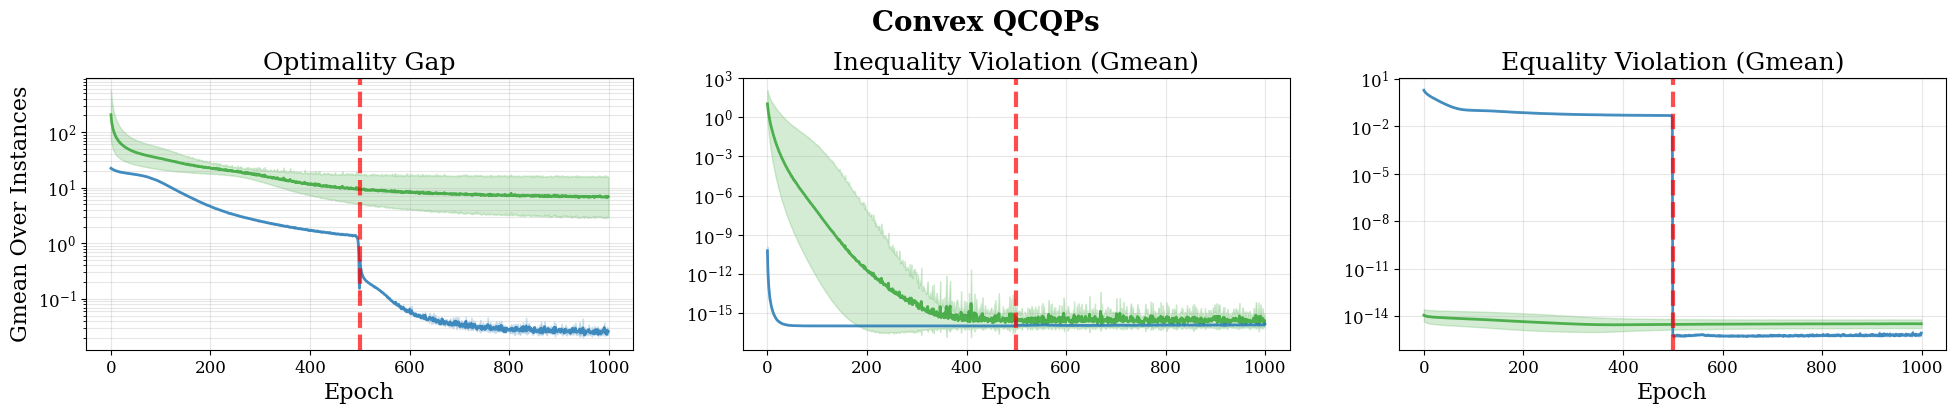

In [11]:
metric_agg = 'gmean'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_opt_metrics(
    history_df=hist_df, 
    methods_to_include=methods_to_include,
    metric_agg=metric_agg,
    figsize=(24, 4),
    show_legend=show_legend,
    suptitle="Convex QCQPs",
    vline_epoch=500,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_opt_metrics_{metric_agg}{legend_txt}'))
plt.show()

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_opt_metrics_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_opt_metrics_max_nolegend.png'


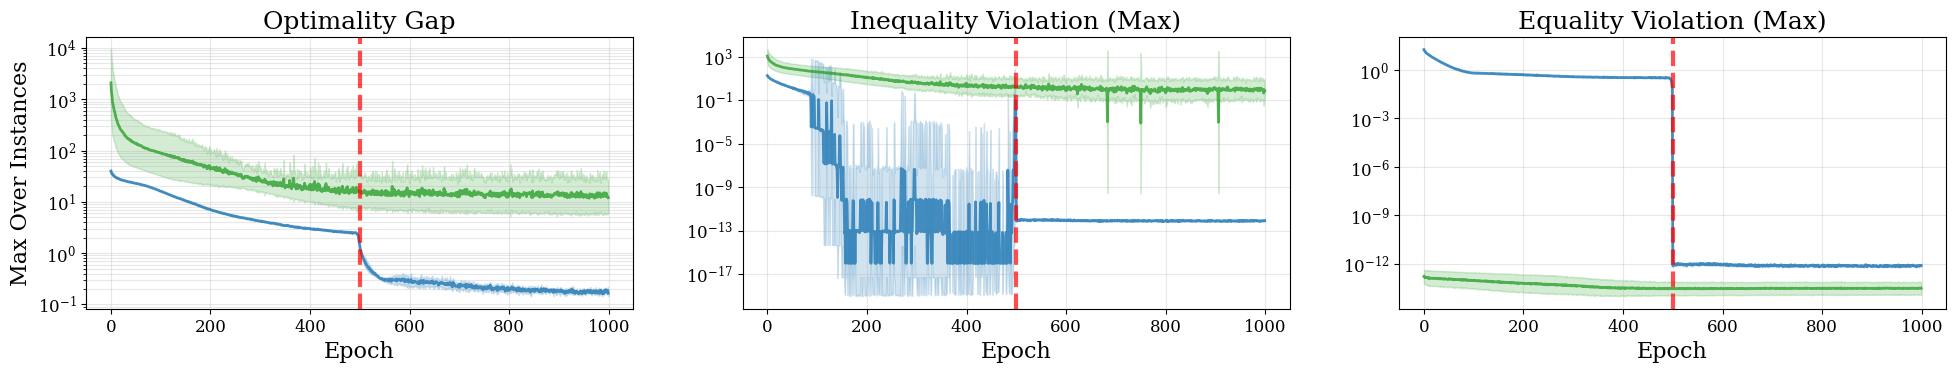

In [12]:
metric_agg = 'max'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_opt_metrics(
    history_df=hist_df, 
    methods_to_include=methods_to_include,
    metric_agg=metric_agg,
    figsize=(24, 4),
    show_legend=show_legend,
    vline_epoch=500,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_opt_metrics_{metric_agg}{legend_txt}'))
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_line_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_line_legend.png'


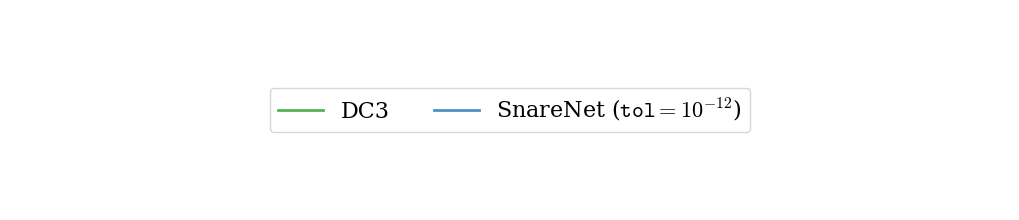

In [13]:
legend_type = 'line'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=hist_df,
    legend_type=legend_type,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_{legend_type}_legend'))
plt.show()

## Test Metrics Bar Chart

In [14]:
# Specify which methods and display names
methods_to_include = {
    'dc3_trainCorr10_testCorr10_corrLr1e-13_corrEps0.0001': r'DC3',
    'hproj_H_Bis': r'HProj',
    'snarenet_pinv_lambda0.01_adaRel500_rtol0.0001':   r'SnareNet ($\mathtt{tol}=10^{-4}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-06':    r'SnareNet ($\mathtt{tol}=10^{-6}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-08':    r'SnareNet ($\mathtt{tol}=10^{-8}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-10':    r'SnareNet ($\mathtt{tol}=10^{-10}$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-12':    r'SnareNet ($\mathtt{tol}=10^{-12}$)',
}

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_test_metrics_bars_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_test_metrics_bars_gmean_nolegend.png'


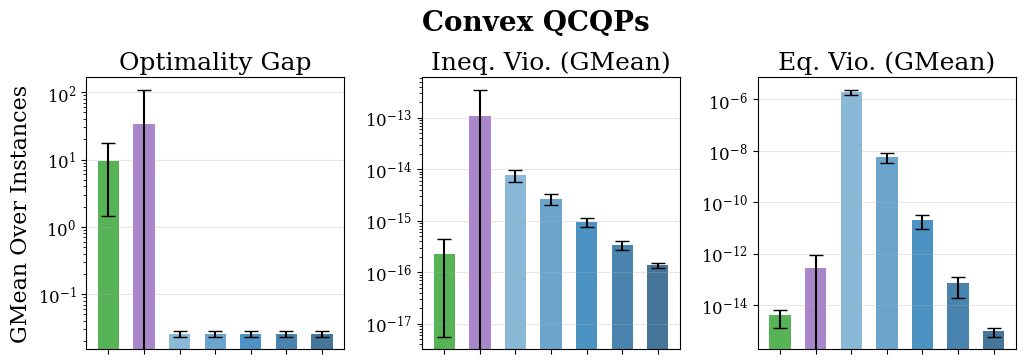

In [15]:
# Plot test metrics as bar charts
metric_agg = 'gmean'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=test_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/ineq_err_{metric_agg}', f'test/eq_err_{metric_agg}'],
    figsize=(12, 4),
    share_ylabel=True,
    suptitle="Convex QCQPs",
    show_legend=show_legend,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_test_metrics_bars_{metric_agg}{legend_txt}'))
plt.show()

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_test_metrics_bars_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_test_metrics_bars_max_nolegend.png'


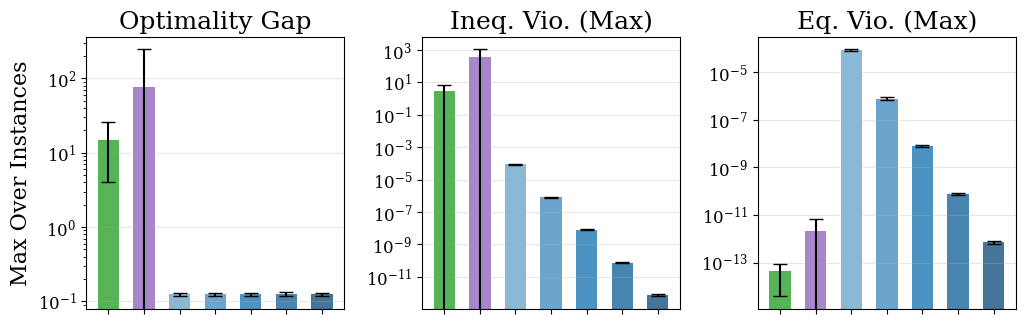

In [16]:
# Plot test metrics as bar charts
metric_agg = 'max'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=test_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/ineq_err_{metric_agg}', f'test/eq_err_{metric_agg}'],
    figsize=(12, 4),
    share_ylabel=True,
    show_legend=show_legend,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_test_metrics_bars_{metric_agg}{legend_txt}'))
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_bar_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_bar_legend.png'


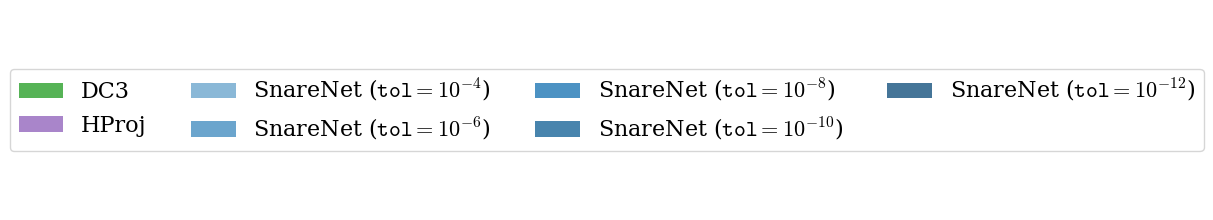

In [17]:
legend_type = 'bar'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=test_df,
    legend_type=legend_type,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_{legend_type}_legend'))
plt.show()

## Test Metrics Table

In [45]:
table = generate_test_metrics_latex_table_from_df(
    test_df=test_df, 
    methods_to_include=methods_to_include)
print(table)

\begin{table*}[h]
\centering
\caption{Evaluation metrics on the test set. Values shown as mean $\pm$ std across random seeds.}
\label{tab:test_metrics}
\resizebox{\linewidth}{!}{
\begingroup
\begin{tabular}{lcccccccc}
\toprule
Method & Max Opt. Gap & GMean Opt. Gap & GMean Ineq. Error & \# Ineq Violations & Max Eq. Error & GMean Eq. Error & \# Eq Violations & Test Time (s) \\
\midrule
DC3 & $(1.67 \pm 0.76) \times 10^{1}$ & $(1.16 \pm 0.57) \times 10^{1}$ & $(1.03 \pm 0.03) \times 10^{-16}$ & $0.03 \pm 0.04$ & $(2.28 \pm 0.63) \times 10^{-14}$ & $(2.31 \pm 0.46) \times 10^{-15}$ & $0.00$ & $0.45 \pm 0.13$ \\
HProj & $(7.78 \pm 17.18) \times 10^{1}$ & $(3.41 \pm 7.57) \times 10^{1}$ & $(1.10 \pm 2.47) \times 10^{-13}$ & $10.00 \pm 22.36$ & $(2.01 \pm 4.41) \times 10^{-12}$ & $(2.77 \pm 6.08) \times 10^{-13}$ & $0.00$ & $0.26 \pm 0.37$ \\
SnareNet ($\mathtt{tol}=10^{-4}$) & $(1.24 \pm 0.06) \times 10^{-1}$ & $(2.60 \pm 0.26) \times 10^{-2}$ & $(7.74 \pm 1.97) \times 10^{-15}$ & $0.00$ & 

# $\lambda$ impact -- noncvx

In [6]:
problem = 'noncvx'

###############################################################################
#################### Replace with your WANDB project name #####################
###############################################################################
project = f"{problem}_lambd_Feb03"
###############################################################################
###############################################################################
###############################################################################

# Get run history and test metrics dataframes
hist_df, test_df = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=project)

In [7]:
# Specify which methods and display names
methods_to_include = {
    'snarenet_pinv_lambda0.001_adaRel500_rtol1e-08':   r'$\mathtt{SnareNet}$ ($\lambda=0.001$)',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-08':    r'$\mathtt{SnareNet}$ ($\lambda=0.01$)',
    'snarenet_pinv_lambda0.1_adaRel500_rtol1e-08': r'$\mathtt{SnareNet}$ ($\lambda=0.1$)',
    'snarenet_pinv_lambda1_adaRel500_rtol1e-08':   r'$\mathtt{SnareNet}$ ($\lambda=1$)',
    'snarenet_pinv_lambda5_adaRel500_rtol1e-08':   r'$\mathtt{SnareNet}$ ($\lambda=5$)',
    'snarenet_pinv_lambda10_adaRel500_rtol1e-08':  r'$\mathtt{SnareNet}$ ($\lambda=10$)',
}

In [8]:
# Obtain last epoch metrics on validation set 
valid_df = hist_df[
    (hist_df['epoch'] == hist_df['epoch'].max())
]

In [9]:
# Count how many seed for each method in test_df3
seed_count = valid_df.groupby('method_name')['seed'].nunique().reset_index()
seed_count.columns = ['method_name', 'num_seeds']

seed_count


,method_name,num_seeds
0,snarenet_pinv_lambda0.0001_adaRel500_rtol1e-08,5
1,snarenet_pinv_lambda0.001_adaRel500_rtol1e-08,5
2,snarenet_pinv_lambda0.1_adaRel500_rtol1e-08,5
3,snarenet_pinv_lambda10_adaRel500_rtol1e-08,5
4,snarenet_pinv_lambda1_adaRel500_rtol1e-08,5
5,snarenet_pinv_lambda5_adaRel500_rtol1e-08,5


Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_lambda_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_lambda_gmean_nolegend.png'


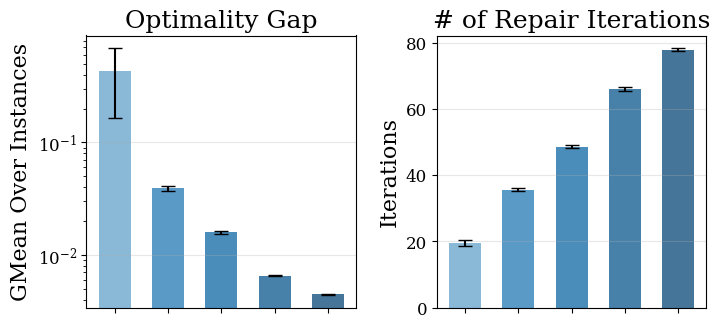

In [14]:
# Plot metrics as bar charts
metric_agg = 'gmean'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=valid_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'valid/opt_gap_{metric_agg}', f'valid/last_iter_taken'],
    figsize=(8, 4),
    show_legend=show_legend,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_lambda_{metric_agg}{legend_txt}'))
plt.show()

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/noncvx_lambda_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/noncvx_lambda_max_nolegend.png'


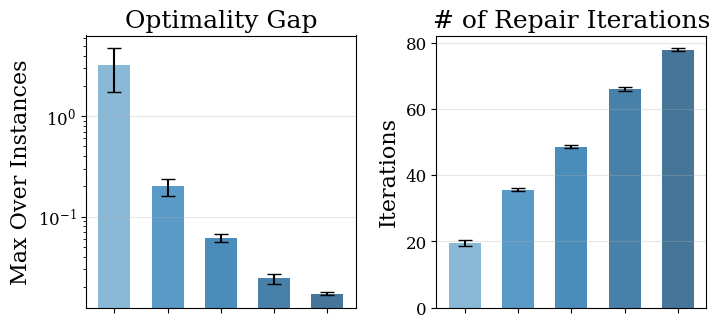

In [15]:
# Plot test metrics as bar charts
metric_agg = 'max'  # Choose between 'max' or 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars(
    test_df=valid_df, 
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'valid/opt_gap_{metric_agg}', f'valid/last_iter_taken'],
    figsize=(8, 4),
    show_legend=show_legend,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_lambda_{metric_agg}{legend_txt}'))
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/lambda_bar_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/lambda_bar_legend.png'


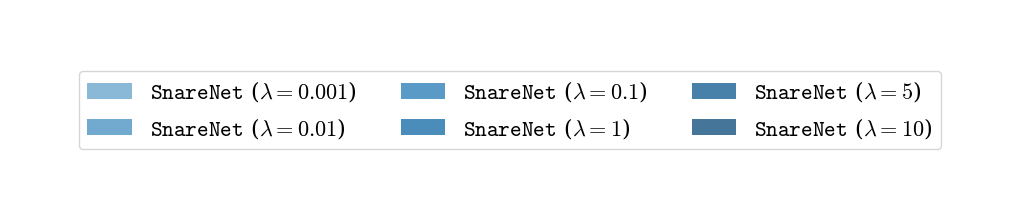

In [16]:
legend_type = 'bar'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=valid_df,
    legend_type=legend_type,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'lambda_{legend_type}_legend'))
plt.show()

# Many Constraints -- cvx_qcqp

In [5]:
problem = 'cvx_qcqp'

###############################################################################
#################### Replace with your WANDB project names ####################
###############################################################################
main_project10 = f"{problem}_ineq10_Feb03"
hproj_project10 = f"HProj_{problem}_Bd100_var100_ineq10_eq50"

main_project50 = f"{problem}_ineq50_Feb03"
hproj_project50 = f"HProj_{problem}_Bd100_var100_ineq50_eq50"

main_project100 = f"{problem}_ineq100_Feb03"
hproj_project100 = f"HProj_{problem}_Bd100_var100_ineq100_eq50"
###############################################################################
###############################################################################
###############################################################################

In [6]:
# Get run history and test metrics dataframes
n_ineq = 10
hist_df10_1, test_df10_1 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=main_project10)
hist_df10_2, test_df10_2 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=hproj_project10)

n_ineq = 50
hist_df50_1, test_df50_1 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=main_project50)
hist_df50_2, test_df50_2 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=hproj_project50)

n_ineq = 100
hist_df100_1, test_df100_1 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=main_project100)
hist_df100_2, test_df100_2 = get_runs_dfs(api, workspace=WANDB_WORKSPACE, project=hproj_project100)

/home/ycchu97/HardConstrainedNN/plot_table_utils.py:220: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(history_dfs, ignore_index=True)
/home/ycchu97/HardConstrainedNN/plot_table_utils.py:220: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  history_df = pd.concat(history_dfs, ignore_index=True)


In [7]:
# Filter for 5 seeds for HProj runs
hist_df10_2 = hist_df10_2[hist_df10_2['seed'].isin(HPROJ_SEEDS)]
test_df10_2 = test_df10_2[test_df10_2['seed'].isin(HPROJ_SEEDS)]

hist_df50_2 = hist_df50_2[hist_df50_2['seed'].isin(HPROJ_SEEDS)]
test_df50_2 = test_df50_2[test_df50_2['seed'].isin(HPROJ_SEEDS)]

hist_df100_2 = hist_df100_2[hist_df100_2['seed'].isin(HPROJ_SEEDS)]
test_df100_2 = test_df100_2[test_df100_2['seed'].isin(HPROJ_SEEDS)]

In [8]:
# Filter test_df10_1 to only include dc3 and Gurobi
test_df10 = pd.concat([
    test_df10_1,
    test_df10_2,
], ignore_index=True)

# Filter test_df50_1 to only include newtonnet with rtol1e-06 and Gurobi
test_df50 = pd.concat([
    test_df50_1,
    test_df50_2,
], ignore_index=True)

# Combine test_df100
test_df100 = pd.concat([
    test_df100_1,
    test_df100_2
], ignore_index=True)

In [16]:
# Rename method_name for DC3 since different hyperparams were used for different n_ineq
# Change to "dc3_trainCorr10_testCorr10"
test_df10['method_name'] = test_df10['method_name'].replace({
    'dc3_trainCorr10_testCorr10_corrLr1e-13_corrEps0.0001': 'dc3_trainCorr10_testCorr10'
})

test_df50['method_name'] = test_df50['method_name'].replace({
    'dc3_trainCorr10_testCorr10_corrLr1e-14_corrEps0.0001': 'dc3_trainCorr10_testCorr10'
})

test_df100['method_name'] = test_df100['method_name'].replace({
    'dc3_trainCorr10_testCorr10_corrLr1e-12_corrEps0.0001': 'dc3_trainCorr10_testCorr10'
})


In [17]:
# Calculate feasibility rate
n_test = 833

for tol in ['1e-1', '1e-2', '1e-4']:
    test_df10[f'test/feasible_rate_{tol}'] = (test_df10[f'test/n_feasible_{tol}']) / n_test*100
    test_df50[f'test/feasible_rate_{tol}'] = (test_df50[f'test/n_feasible_{tol}']) / n_test*100
    test_df100[f'test/feasible_rate_{tol}'] = (test_df100[f'test/n_feasible_{tol}']) / n_test*100

In [18]:
# Specify which methods to compare (update when you have more methods)
methods_to_include = {
    'cvxpy_tol0.0001':                                          'Optimizer (Gurobi)',
    'dc3_trainCorr10_testCorr10':     'DC3',
    'hproj_H_Bis':                                              'HProj',
    'snarenet_pinv_lambda0.01_adaRel500_rtol1e-06':             'SnareNet (Ours)',
}

# Create dictionary mapping group labels to test dataframes
test_dfs_dict = {
    '10': test_df10,
    '50': test_df50,
    '100': test_df100,
}

Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_ineq_gmean_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_ineq_gmean_nolegend.png'


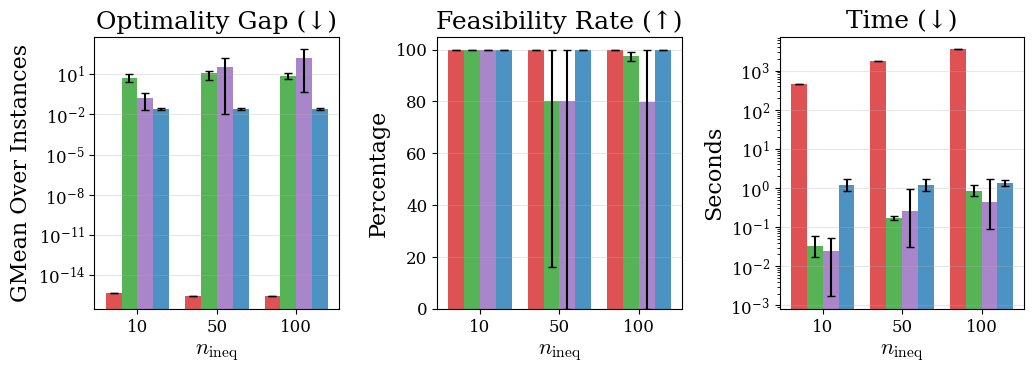

In [ ]:
# Plot grouped bar charts - gmean aggregation
metric_agg = 'gmean'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars_groups(
    test_dfs_dict=test_dfs_dict,
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/feasible_rate_1e-4', 'test/time'],
    figsize=(12, 4),
    show_legend=show_legend,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_ineq_{metric_agg}{legend_txt}'),
    quartiles=True)
plt.show()

Remove the following (method, seed, group) due to NaN values:
  - dc3_trainCorr10_testCorr10_corrLr1e-12_corrEps0.0001, seed=101, group=10, metric=test/opt_gap_max
  - dc3_trainCorr10_testCorr10_corrLr1e-12_corrEps0.0001, seed=456, group=50, metric=test/opt_gap_max
Plots saved as '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_ineq_max_nolegend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/cvx_qcqp_ineq_max_nolegend.png'


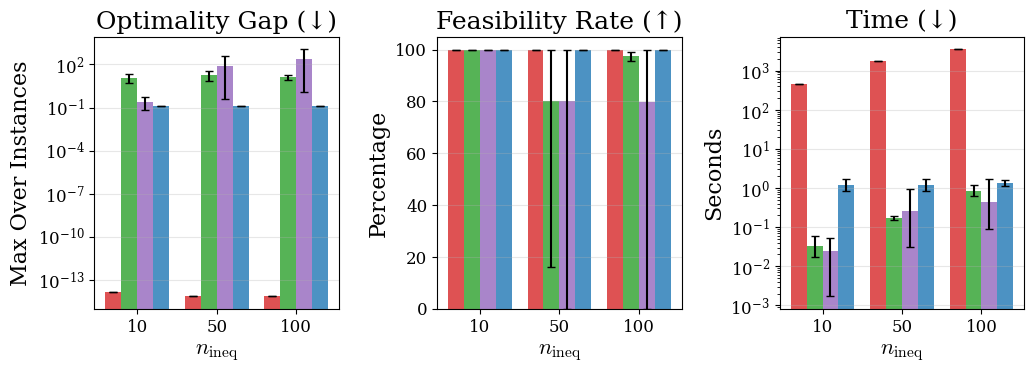

In [19]:
# Plot grouped bar charts - max aggregation
metric_agg = 'max'
show_legend = False
legend_txt = '_nolegend' if not show_legend else ''

fig, axes = plot_test_metrics_bars_groups(
    test_dfs_dict=test_dfs_dict,
    methods_to_include=methods_to_include,
    metrics_to_plot=[f'test/opt_gap_{metric_agg}', f'test/feasible_rate_1e-4', 'test/time'],
    figsize=(12, 4),
    show_legend=show_legend,
    legend_ncol=3,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'{problem}_ineq_{metric_agg}{legend_txt}'),
    quartiles=True)
plt.show()

Legend saved as '/home/ycchu97/HardConstrainedNN/figures/ineq_bar_legend.pdf' and '/home/ycchu97/HardConstrainedNN/figures/ineq_bar_legend.png'


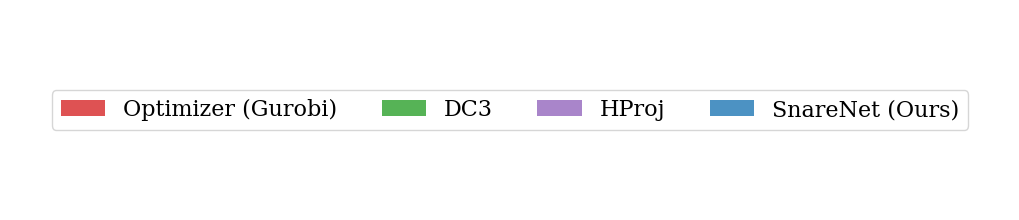

In [21]:
legend_type = 'bar'

legend_fig = plot_legend(
    methods_to_include=methods_to_include, 
    history_df=test_df10,
    legend_type=legend_type,
    legend_ncol=4,
    save_path=os.path.join(FIGURE_SAVE_DIR, f'ineq_{legend_type}_legend'))
plt.show()

## Test Metrics Table

In [54]:
# Generate latex code for test metrics table (10 inequalities)
table = generate_test_metrics_latex_table_from_df(
    test_df=test_df10, 
    methods_to_include=methods_to_include)

print(table)

\begin{table*}[h]
\centering
\caption{Evaluation metrics on the test set. Values shown as mean $\pm$ std across random seeds.}
\label{tab:test_metrics}
\resizebox{\linewidth}{!}{
\begingroup
\begin{tabular}{lcccccccc}
\toprule
Method & Max Opt. Gap & GMean Opt. Gap & GMean Ineq. Error & \# Ineq Violations & Max Eq. Error & GMean Eq. Error & \# Eq Violations & Test Time (s) \\
\midrule
Optimizer (Gurobi) & $1.42 \times 10^{-14}$ & $4.48 \times 10^{-16}$ & $0.00$ & $0.00$ & $5.43 \times 10^{-10}$ & $1.06 \times 10^{-14}$ & $0.00$ & $428.44$ \\
DC3 & $(7.96 \pm 11.33) \times 10^{1}$ & $(2.21 \pm 1.94) \times 10^{1}$ & $(3.52 \pm 7.87) \times 10^{-10}$ & $0.97 \pm 1.88$ & $(1.48 \pm 1.11) \times 10^{-13}$ & $(1.40 \pm 0.94) \times 10^{-14}$ & $0.00$ & $0.08 \pm 0.07$ \\
HProj & $(2.40 \pm 1.99) \times 10^{-1}$ & $(1.60 \pm 1.42) \times 10^{-1}$ & $0.00$ & $0.00$ & $(1.08 \pm 0.92) \times 10^{-13}$ & $(1.41 \pm 0.98) \times 10^{-14}$ & $0.00$ & $0.02 \pm 0.02$ \\
SnareNet (Ours) & $(1.74 \p

In [55]:
# Generate latex code for test metrics table (50 inequalities)
table = generate_test_metrics_latex_table_from_df(
    test_df=test_df50, 
    methods_to_include=methods_to_include)

print(table)

\begin{table*}[h]
\centering
\caption{Evaluation metrics on the test set. Values shown as mean $\pm$ std across random seeds.}
\label{tab:test_metrics}
\resizebox{\linewidth}{!}{
\begingroup
\begin{tabular}{lcccccccc}
\toprule
Method & Max Opt. Gap & GMean Opt. Gap & GMean Ineq. Error & \# Ineq Violations & Max Eq. Error & GMean Eq. Error & \# Eq Violations & Test Time (s) \\
\midrule
Optimizer (Gurobi) & $7.11 \times 10^{-15}$ & $2.74 \times 10^{-16}$ & $1.01 \times 10^{-16}$ & $0.00$ & $1.58 \times 10^{-8}$ & $3.89 \times 10^{-13}$ & $0.00$ & $1742.79$ \\
DC3 & $(3.37 \pm 1.78) \times 10^{1}$ & $(1.59 \pm 0.76) \times 10^{1}$ & $(2.39 \pm 4.72) \times 10^{-13}$ & $5.33 \pm 5.07$ & $(7.63 \pm 5.12) \times 10^{-14}$ & $(5.42 \pm 3.01) \times 10^{-15}$ & $0.00$ & $0.18 \pm 0.08$ \\
HProj & $(7.78 \pm 17.18) \times 10^{1}$ & $(3.41 \pm 7.57) \times 10^{1}$ & $(1.10 \pm 2.47) \times 10^{-13}$ & $10.00 \pm 22.36$ & $(2.01 \pm 4.41) \times 10^{-12}$ & $(2.77 \pm 6.08) \times 10^{-13}$ & $0.

In [56]:
# Generate latex code for test metrics table (100 inequalities)
table = generate_test_metrics_latex_table_from_df(
    test_df=test_df100, 
    methods_to_include=methods_to_include)

print(table)

\begin{table*}[h]
\centering
\caption{Evaluation metrics on the test set. Values shown as mean $\pm$ std across random seeds.}
\label{tab:test_metrics}
\resizebox{\linewidth}{!}{
\begingroup
\begin{tabular}{lcccccccc}
\toprule
Method & Max Opt. Gap & GMean Opt. Gap & GMean Ineq. Error & \# Ineq Violations & Max Eq. Error & GMean Eq. Error & \# Eq Violations & Test Time (s) \\
\midrule
Optimizer (Gurobi) & $7.11 \times 10^{-15}$ & $2.57 \times 10^{-16}$ & $1.04 \times 10^{-16}$ & $0.00$ & $1.57 \times 10^{-7}$ & $7.90 \times 10^{-13}$ & $0.00$ & $3563.30$ \\
DC3 & $(1.14 \pm 0.66) \times 10^{1}$ & $6.86 \pm 4.63$ & $(1.42 \pm 0.91) \times 10^{-16}$ & $0.65 \pm 1.37$ & $(1.76 \pm 1.27) \times 10^{-14}$ & $(1.70 \pm 0.89) \times 10^{-15}$ & $0.00$ & $0.48 \pm 0.08$ \\
HProj & $(2.35 \pm 5.22) \times 10^{2}$ & $(1.53 \pm 3.40) \times 10^{2}$ & $(5.40 \pm 12.08) \times 10^{-11}$ & $20.07 \pm 44.86$ & $(1.83 \pm 4.03) \times 10^{-12}$ & $(3.04 \pm 6.73) \times 10^{-13}$ & $0.00$ & $0.44 \pm 